# TP Régression linéaire — Exercice 2 : régression multivariée (forme matricielle)
47 logements à Portland : surface et nombre de pièces (`ex2x.dat`) → prix (`ex2y.dat`).

## 1. Lecture des données

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.loadtxt('ex2x.dat')
y = np.loadtxt('ex2y.dat')
m = len(y)
print(x.shape, y.shape)

(47, 2) (47,)


## 2. Normalisation (centrage-réduction)

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_norm = scaler.fit_transform(x)
print(x_norm.mean(axis=0), x_norm.std(axis=0))

# matrice augmentée (colonne de 1) et cible
X = np.hstack([np.ones((m, 1)), x_norm])
Y = y.reshape(-1, 1)

[-9.44870659e-18  2.48028548e-16] [1. 1.]


## 3. Fonctions matricielles
$h_\theta(X)=X\theta$, $E=h_\theta(X)-Y$, $J(\theta)=\frac{1}{2m}E^TE$, $\theta^*=\theta-\frac{\alpha}{m}X^TE$.

In [3]:
def h(theta, X):
    return X @ theta

def E(theta, X, Y):
    return h(theta, X) - Y

def J(theta, X=X, Y=Y):
    e = E(theta, X, Y)
    return (e.T @ e).item() / (2 * len(Y))

def iteration(theta, alpha, X=X, Y=Y):
    return theta - alpha / len(Y) * X.T @ E(theta, X, Y)

## 4. Régression avec α = 0,07 (jusqu'à convergence, $\varepsilon=10^{-10}$)

In [4]:
EPS = 1e-10  # seuil du critère d'arrêt
def descente(alpha, eps=EPS, max_iter=100000):
    theta = np.zeros((X.shape[1], 1))
    for k in range(max_iter):
        j_old = J(theta)
        theta = iteration(theta, alpha)
        if abs((J(theta) - j_old) / j_old) < eps:
            break
    return theta, k + 1

theta, n = descente(0.07)
print('itérations :', n)
print('theta =', theta.ravel(), ' J =', J(theta))

itérations : 320
theta = [340412.65954651 109445.19339598  -6575.7517805 ]  J = 2043280053.584488


## 5. Choix du taux d'apprentissage α ∈ [0,001 ; 10]
50 itérations pour chaque α, en stockant $J(\theta)$ à chaque itération.

α=0.001  J après 50 it. = 5.941e+10
α=0.003  J après 50 it. = 4.883e+10
α=0.01   J après 50 it. = 2.506e+10
α=0.03   J après 50 it. = 5.225e+09
α=0.1    J après 50 it. = 2.061e+09
α=0.3    J après 50 it. = 2.043e+09
α=1      J après 50 it. = 2.043e+09
α=3      J après 50 it. = 1.582e+66
α=10     J après 50 it. = 1.122e+126


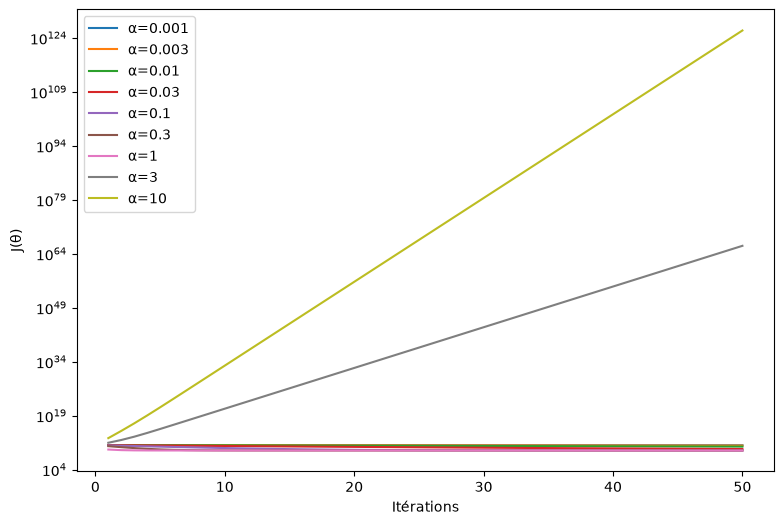

In [5]:
alphas = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]
plt.figure(figsize=(9, 6))
for a in alphas:
    theta_a = np.zeros((3, 1)); hist = []
    for k in range(50):
        theta_a = iteration(theta_a, a)
        hist.append(J(theta_a))
    plt.plot(range(1, 51), hist, label=f'α={a}')
    print(f'α={a:<6} J après 50 it. = {hist[-1]:.4g}')
plt.yscale('log'); plt.xlabel('Itérations'); plt.ylabel('J(θ)'); plt.legend(); plt.show()

**Choix :** les α trop petits (0,001 ; 0,003) convergent lentement, les α ≥ 3 divergent. Parmi les valeurs qui convergent, α = 1 (comme 0,3) est le plus rapide (convergence quasi immédiate) ; on le retient.

In [6]:
alpha_opt = 1
theta_opt, n = descente(alpha_opt)
print('itérations :', n, ' theta =', theta_opt.ravel(), ' J =', J(theta_opt))

# vérification avec la solution exacte (équations normales)
print('solution exacte :', np.linalg.solve(X.T @ X, X.T @ Y).ravel())

itérations : 22  theta = [340412.65957447 109447.48112602  -6578.33590045]  J = 2043280050.6493816
solution exacte : [340412.65957447 109447.79646964  -6578.35485416]


### Prédiction : logement de 1650 m² et 3 pièces
Le point doit être normalisé avec le même `scaler`.

In [7]:
new = scaler.transform([[1650, 3]])
x_new = np.hstack([np.ones((1, 1)), new])
print(f'Prix prédit : {h(theta_opt, x_new).item():.0f}')

Prix prédit : 293082
